In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load Dataset
df = pd.read_csv("weatherHistory.csv")

# Display Dataset
print(df.head())

# Check Missing Values
print(df.isnull().sum())

# Remove Missing Values
df = df.dropna()

# Convert Categorical Columns into Numeric
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Separate Features and Target
X = df.drop("Summary", axis=1)
y = df["Summary"]

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [4]:
import torch
import torch.nn as nn

# Convert to Tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

# Neural Network

class StudentModel(nn.Module):

    def __init__(self,input_size,num_classes):

        super(StudentModel,self).__init__()

        self.fc1 = nn.Linear(input_size,64)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(64,32)

        self.fc3 = nn.Linear(32,num_classes)

    def forward(self,x):

        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)

        return x

input_size = X_train.shape[1]
num_classes = len(np.unique(y_train))

model = StudentModel(input_size,num_classes)

print(model)

StudentModel(
  (fc1): Linear(in_features=11, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=27, bias=True)
)


In [5]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

epochs = 50

loss_history=[]

for epoch in range(epochs):

    outputs=model(X_train)

    loss=criterion(outputs,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1)%5==0:

        print(f"Epoch {epoch+1}/{epochs}  Loss={loss.item():.4f}")

Epoch 5/50  Loss=3.1797
Epoch 10/50  Loss=3.1025
Epoch 15/50  Loss=3.0092
Epoch 20/50  Loss=2.8917
Epoch 25/50  Loss=2.7474
Epoch 30/50  Loss=2.5794
Epoch 35/50  Loss=2.3964
Epoch 40/50  Loss=2.2101
Epoch 45/50  Loss=2.0326
Epoch 50/50  Loss=1.8728


In [6]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model.eval()

with torch.no_grad():

    outputs=model(X_test)

    _,predicted=torch.max(outputs,1)

accuracy=accuracy_score(y_test,predicted)

print("Accuracy =",accuracy)

print("\nClassification Report\n")

print(classification_report(y_test,predicted))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test,predicted))

Accuracy = 0.3764853033145716

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00        95
           4       0.00      0.00      0.00       108
           5       0.00      0.00      0.00        77
           6       0.00      0.00      0.00      2161
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00         7
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00        17
          12       0.00      0.00      0.00      1373
          13       0.00      0.00      0.00         9
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         4
          16       0.00      0.00      0.00        13
          17       0.31      0.85      0.45      5566
          18       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


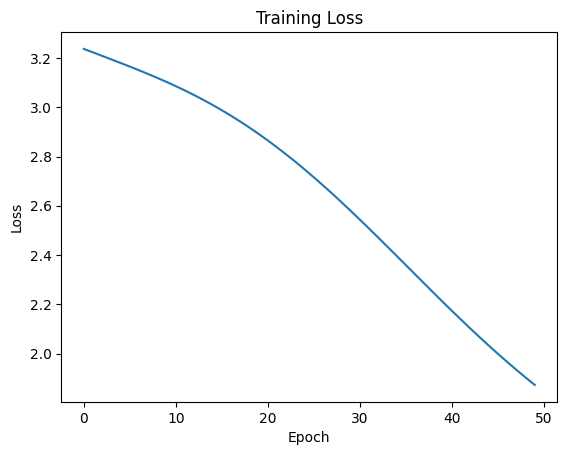

In [7]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

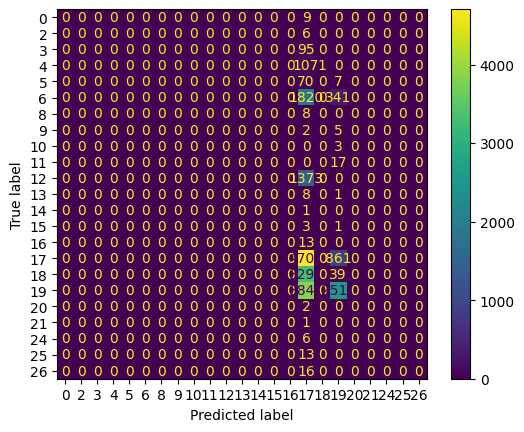

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,predicted)

plt.show()